In [22]:
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re

import matplotlib.pyplot as plt

import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, GRU , SimpleRNN

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [27]:
df = pd.read_csv('combined_data.csv', engine='python', on_bad_lines='skip')

In [28]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [29]:
df.isnull().sum()

,0
label,0
text,0


In [30]:
df.shape

(28573, 2)

In [31]:
df['text'] = df['text'].str.lower()

In [32]:
def remove_special(text):
  return text.translate (str.maketrans('', '', string.punctuation))

df['text'] = df['text'].apply(remove_special)

In [33]:
def remove_special(text):
  return text.translate (str.maketrans('', '', string.punctuation))

df['text'] = df['text'].apply(remove_special)

In [34]:
Stops = set(stopwords.words('english'))

In [35]:
def  remove_stopwords(text):
  return [word for word in text if word not in Stops]

df['text'] = df['text'].apply(word_tokenize)
df['text'] = df['text'].apply(remove_stopwords)

In [36]:
df.head()

,label,text
0,1,"[ounce, feather, bowl, hummingbird, opec, mome..."
1,1,"[wulvob, get, medircations, online, qnb, ikud,..."
2,0,"[computer, connection, cnn, com, wednesday, es..."
3,1,"[university, degree, obtain, prosperous, futur..."
4,0,"[thanks, answers, guys, know, checked, rsync, ..."


In [37]:
df['text'] = df['text'].apply(' '.join)

In [38]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


In [39]:
def remove_hyperlink(word):
    return re.sub(r"http\S+", "", word)

df['text'] = df['text'].apply(remove_hyperlink)

In [40]:
import pandas as pd
import re
from collections import Counter

# 1. Filter only spam emails
spam_df = df[df['label'] == 1]   # change to == 1 if spam is labeled as 1

# 2. Combine all spam text into one string
all_spam_text = " ".join(spam_df['text'])

# 3. Clean text (lowercase, remove special characters & numbers)
all_spam_text = all_spam_text.lower()
all_spam_text = re.sub(r'[^a-z\s]', '', all_spam_text)

# 4. Split into words
words = all_spam_text.split()

# 5. Count word frequencies
word_freq = Counter(words)

# 6. Get Top 10 most common words
top_10_words = word_freq.most_common(10)

print("Top 10 most frequent words in SPAM emails:")
for word, freq in top_10_words:
    print(f"{word} : {freq}")

Top 10 most frequent words in SPAM emails:
escapenumber : 119185
escapelong : 62161
per : 9871
com : 9754
http : 9584
x : 9174
pills : 8881
escapenumbermg : 8015
price : 6193
item : 5880


In [41]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [42]:
max_features = 5000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [43]:
average_length = sum(map(len, X_train_seq)) / len(X_train_seq)

In [44]:
max_length = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length,padding = 'post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length,padding = 'post')

In [45]:
max_features = 5000
max_length = 500
embedding_length = 32

In [46]:
model_rnn = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    SimpleRNN(64),

    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
model_gru = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    GRU(64,use_cudnn=False),

    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
EPOCHS = 10
BATCH_SIZE = 64

In [50]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9135 - loss: 0.2318 - val_accuracy: 0.9668 - val_loss: 0.1082
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9780 - loss: 0.0733 - val_accuracy: 0.9755 - val_loss: 0.0804
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9795 - loss: 0.0662 - val_accuracy: 0.9760 - val_loss: 0.0772
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9909 - loss: 0.0312 - val_accuracy: 0.9741 - val_loss: 0.0795
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.9944 - loss: 0.0216 - val_accuracy: 0.9755 - val_loss: 0.0910
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.9954 - loss: 0.0170 - val_accuracy: 0.9734 - val_loss: 0.0900
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9965 - loss: 0.0140 - val_accuracy: 0.9749 - val_loss: 0.0826
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9967 - loss: 0.0118 - 

In [51]:
import numpy as np

y_pred_prob = model_rnn.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


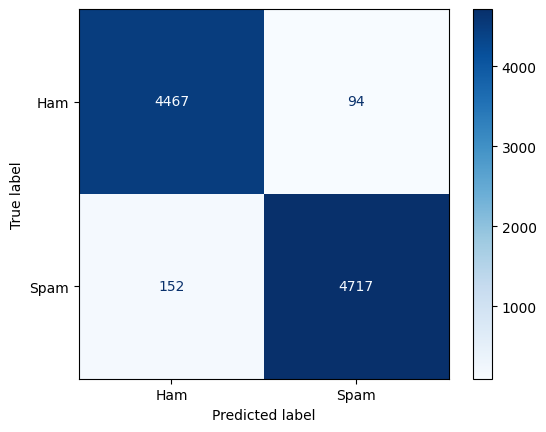

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)
disp.plot(cmap='Blues')
plt.show()

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4561
           1       0.98      0.97      0.97      4869

    accuracy                           0.97      9430
   macro avg       0.97      0.97      0.97      9430
weighted avg       0.97      0.97      0.97      9430



In [54]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9435 - loss: 0.1658 - val_accuracy: 0.9766 - val_loss: 0.0817
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9821 - loss: 0.0626 - val_accuracy: 0.9780 - val_loss: 0.0716
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9888 - loss: 0.0403 - val_accuracy: 0.9786 - val_loss: 0.0718
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9916 - loss: 0.0303 - val_accuracy: 0.9786 - val_loss: 0.0823
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9943 - loss: 0.0226 - val_accuracy: 0.9768 - val_loss: 0.0851
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9934 - loss: 0.0247 - val_accuracy: 0.9791 - val_loss: 0.0812
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9961 - loss: 0.0162 - val_accuracy: 0.9785 - val_loss: 0.0840
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9952 - loss: 0.0175 - 

In [55]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9281 - loss: 0.1700 - val_accuracy: 0.9792 - val_loss: 0.0716
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.9858 - loss: 0.0479 - val_accuracy: 0.9802 - val_loss: 0.0677
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.9905 - loss: 0.0360 - val_accuracy: 0.9809 - val_loss: 0.0669
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.9903 - loss: 0.0357 - val_accuracy: 0.9788 - val_loss: 0.0731
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.9939 - loss: 0.0232 - val_accuracy: 0.9794 - val_loss: 0.0723
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.9944 - loss: 0.0255 - val_accuracy: 0.9788 - val_loss: 0.0781
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.9947 - loss: 0.0213 - val_accuracy: 0.9810 - val_loss: 0.0769
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.9967 - loss: 0.0152 - 

In [56]:
import numpy as np

y_pred_prob_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [57]:
from sklearn.metrics import accuracy_score

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.9773064687168611


In [58]:
from sklearn.metrics import classification_report

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=["Ham", "Spam"]))

LSTM Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98      4561
        Spam       0.98      0.98      0.98      4869

    accuracy                           0.98      9430
   macro avg       0.98      0.98      0.98      9430
weighted avg       0.98      0.98      0.98      9430



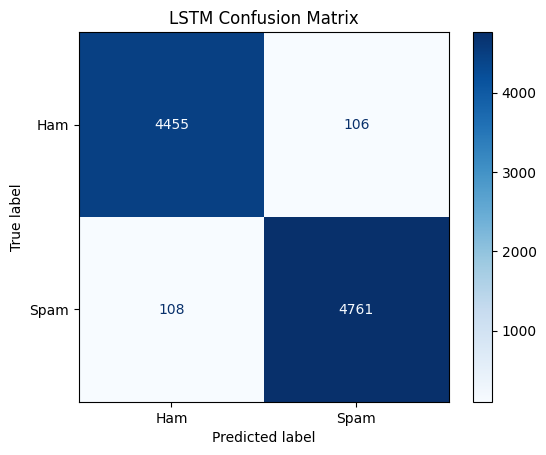

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.show()

In [60]:
y_pred_prob_gru = model_gru.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


In [61]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
print("GRU Accuracy:", gru_accuracy)

GRU Accuracy: 0.9795334040296925


In [62]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=["Ham", "Spam"]))

GRU Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98      4561
        Spam       0.97      0.99      0.98      4869

    accuracy                           0.98      9430
   macro avg       0.98      0.98      0.98      9430
weighted avg       0.98      0.98      0.98      9430



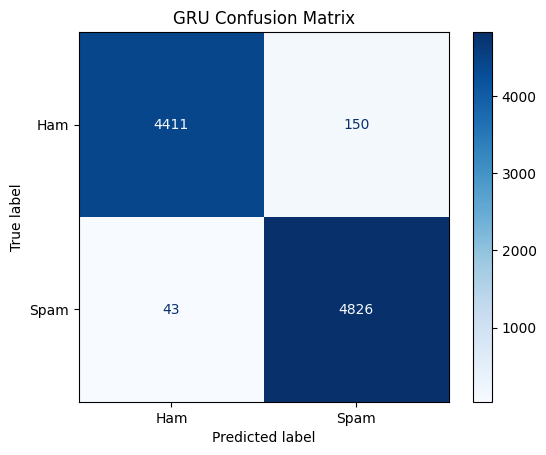

In [63]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("GRU Confusion Matrix")
plt.show()


In [64]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    }

In [65]:
results = []

results.append(evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN"))
results.append(evaluate_model(model_lstm, X_test_pad, y_test, "LSTM"))
results.append(evaluate_model(model_gru, X_test_pad, y_test, "GRU"))

results_df = pd.DataFrame(results)
print(results_df)

295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
        Model  Accuracy  Spam Precision  Spam Recall   Spam F1
0  Simple RNN  0.973913        0.980461     0.968782  0.974587
1        LSTM  0.977306        0.978221     0.977819  0.978020
2         GRU  0.979533        0.969855     0.991169  0.980396


In [66]:
best_model_row = results_df.sort_values(
    by="Spam F1",
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model_row)

Best Model:
Model                  GRU
Accuracy          0.979533
Spam Precision    0.969855
Spam Recall       0.991169
Spam F1           0.980396
Name: 2, dtype: object


In [67]:
model_gru.save("gru_model.keras")

In [68]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [69]:
config = {
    "max_features": max_features,
    "max_length": max_length,
    "embedding_length": embedding_length
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

In [70]:
label_mapping = {0: "Ham", 1: "Spam"}

with open("label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)